In [1]:
import numpy as np
from loadmodules import *
import scipy as sp
import matplotlib.pyplot as plt

%matplotlib inline
rcParams['figure.facecolor'] = 'white'

In [26]:
simulation_list = ['./level4/Au06_cfea_fiducial', './level5/Au06_e5813_fiducial', './level6/Au06_e5813_fiducial']
variations = ['Level 4', 'Level 5', 'Level 6']

compare_lifetime = []
compare_initialrh = []
compare_finalrh = []
compare_initialmass = []
compare_finalmass = []
compare_mlshock = []
compare_mlrelax = []
compare_tteig = []
compare_radii = []

solar_mass_g = 1.989e33
Gcosmo = 43.
G_cgs = 6.6738e-8 # cm^3 g^-1 s^-2
k = 1.3807e-16 # boltzmann constant in erg/K (g*cm^2/s^2/K)
parsec = 3.08567758e18 # cm
gyr = 3.15576e16 # seconds

In [27]:
for sim in simulation_list:
    snap_id = 127
    print('Loading simulation ', sim, ' snapshot ', snap_id)
    sf = load_subfind(snap_id, dir=sim+'/output/', hdf5=True, loadonly=['fpos', 'frc2', 'svel', 'flty', 'fnsh', 'slty', 'spos', 'smty', 'ffsh'] )
    s = gadget_readsnap(snap_id, snappath=sim+'/output/', subfind=sf, hdf5=True, applytransformationfacs=True, loadonlyhalo=0, loadonlytype=[4])
    s.calc_sf_indizes( sf )
    s.select_halo( sf, use_principal_axis=True, use_cold_gas_spin=False, do_rotation=True )

    s.parameters['UnitTime_in_s'] = s.parameters['UnitLength_in_cm']/s.parameters['UnitVelocity_in_cm_per_s']

    galrad = sf.data['frc2'][0]
    starparts = (s.data['age']>0.) * (s.r()<galrad) * (s.data['subhalo']==0)

    mask_cluster_initial = (s.data['incl'][starparts]>0)
    cluster_masses = s.data['mclt'][starparts][mask_cluster_initial].flatten()*s.UnitMass_in_g/solar_mass_g
    cluster_radius = s.data['rclt'][starparts][mask_cluster_initial].flatten()*s.UnitLength_in_cm/parsec
    init_cluster_masses = s.data['imcl'][starparts][mask_cluster_initial].flatten()*s.UnitMass_in_g/solar_mass_g
    init_cluster_radius = s.data['ircl'][starparts][mask_cluster_initial].flatten()*s.UnitLength_in_cm/parsec
    masslostrelax = s.data['mlrx'][starparts][mask_cluster_initial].flatten()*s.UnitMass_in_g/solar_mass_g
    masslostshock = s.data['mlsk'][starparts][mask_cluster_initial].flatten()*s.UnitMass_in_g/solar_mass_g

    not_empty_clusters = (init_cluster_masses>0)

    cluster_masses = cluster_masses[not_empty_clusters]
    cluster_radius = cluster_radius[not_empty_clusters]
    init_cluster_masses = init_cluster_masses[not_empty_clusters]
    init_cluster_radius = init_cluster_radius[not_empty_clusters]
    masslostrelax = masslostrelax[not_empty_clusters]
    masslostshock = masslostshock[not_empty_clusters]

    clusters_formtime = np.repeat(s.data['age'][starparts][mask_cluster_initial], s.data['incl'][starparts][mask_cluster_initial])
    clusters_age = s.cosmology_get_lookback_time_from_a(clusters_formtime, is_flat=True) - s.cosmology_get_lookback_time_from_a(s.time, is_flat=True)

    cluster_disruptiontime = s.data['drpt'][starparts][mask_cluster_initial].flatten()
    cluster_disruptiontime = s.cosmology_get_lookback_time_from_a(cluster_disruptiontime[not_empty_clusters], is_flat=True)

    lifetime_gyr = clusters_age - cluster_disruptiontime
    lifetime_gyr[lifetime_gyr<0] = 20.

    TTij = s.data['ttij'][starparts][mask_cluster_initial] / s.parameters['UnitTime_in_s']**2 * gyr**2
    TTeig = np.linalg.eigvalsh(TTij.reshape(mask_cluster_initial.sum(), 3, 3))
    TTeig = np.sort(TTeig, axis=1)

    compare_initialmass.append(init_cluster_masses)
    compare_initialrh.append(init_cluster_radius)
    compare_finalrh.append(cluster_radius)
    compare_finalmass.append(cluster_masses)
    compare_mlshock.append(masslostshock)
    compare_mlrelax.append(masslostrelax)
    compare_tteig.append(TTeig)
    compare_radii.append(s.r()[starparts][mask_cluster_initial])
    compare_lifetime.append(lifetime_gyr)

Loading simulation  ./level4/Au06_cfea_fiducial  snapshot  127
galrad= 0.021391647
Found 1370901 stars.
Rotated pos.
Rotated vel.
Loading simulation  ./level5/Au06_e5813_fiducial  snapshot  127
galrad= 0.021445496
Found 173049 stars.
Rotated pos.
Rotated vel.
Loading simulation  ./level6/Au06_e5813_fiducial  snapshot  127
galrad= 0.021225145
Found 11621 stars.
Rotated pos.
Rotated vel.


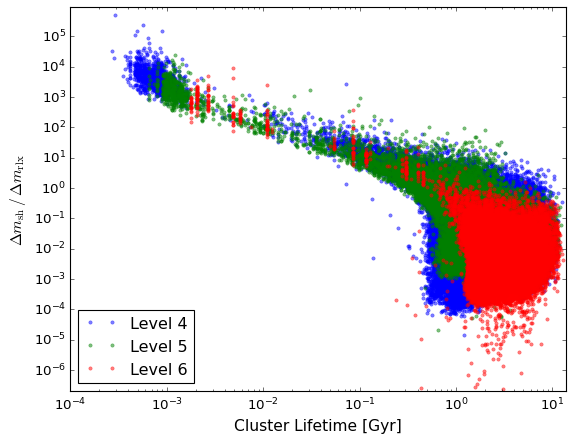

In [8]:
for i in range(len(simulation_list)):
    plt.loglog(compare_lifetime[i], compare_mlshock[i]/compare_mlrelax[i], '.', label=variations[i], alpha=0.5)
plt.xlabel('Cluster Lifetime [Gyr]', fontsize=14)
plt.ylabel(r'$\Delta m_\mathrm{sh} \, / \, \Delta m_\mathrm{rlx}$', fontsize=14)
plt.xlim(1e-4, 14)
plt.ylim(2e-7, 9e5)
plt.legend(loc=3, scatterpoints=1)

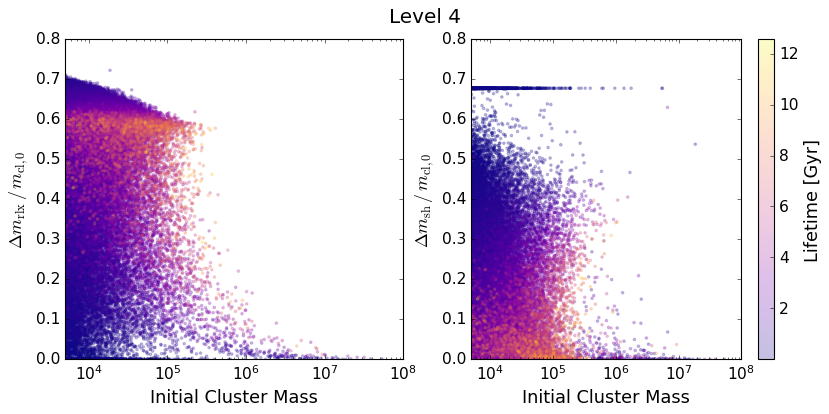

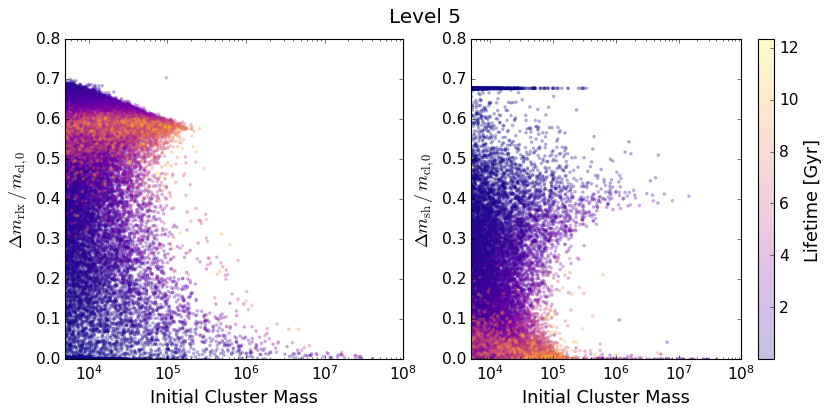

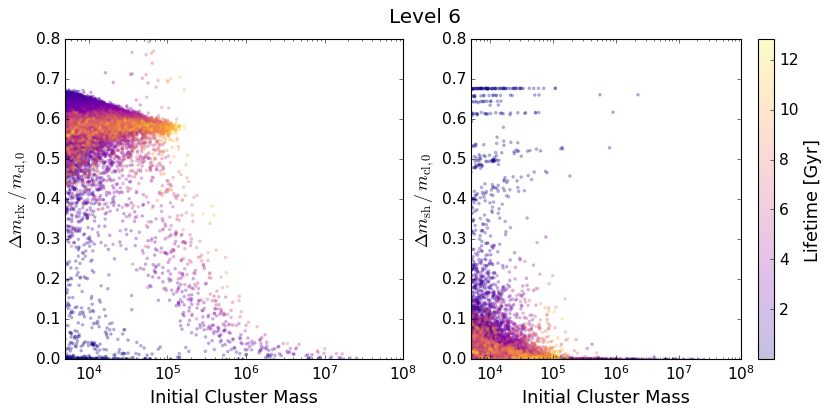

In [9]:
for i in range(len(simulation_list)):
    fig, ax = plt.subplots(1, 2, figsize=(12,5))

    h = ax[0].scatter(compare_initialmass[i][compare_lifetime[i]<16], compare_mlrelax[i][compare_lifetime[i]<16]/compare_initialmass[i][compare_lifetime[i]<16],
                      s=5, c=compare_lifetime[i][compare_lifetime[i]<16], cmap=cm.plasma, edgecolors='face', alpha=0.25)
    ax[0].set_xlabel('Initial Cluster Mass', fontsize=16)
    ax[0].set_ylabel(r'$\Delta m_\mathrm{rlx} \, / \, m_{\rm{cl,0}}$', fontsize=16)
    ax[0].set_xscale('log')
    # ax[0].set_yscale('log')
    ax[0].set_xlim(5e3, 1e8)
    ax[0].set_ylim(0, 0.8)
    ax[0].tick_params(labelsize=14)

    h = ax[1].scatter(compare_initialmass[i][compare_lifetime[i]<16], compare_mlshock[i][compare_lifetime[i]<16]/compare_initialmass[i][compare_lifetime[i]<16],
                      s=5, c=compare_lifetime[i][compare_lifetime[i]<16], cmap=cm.plasma, edgecolors='face', alpha=0.25)
    ax[1].set_xlabel('Initial Cluster Mass', fontsize=16)
    ax[1].set_ylabel(r'$\Delta m_\mathrm{sh} \, / \, m_{\rm{cl,0}}$', fontsize=16)
    ax[1].set_xscale('log')
    # ax[1].set_yscale('log')
    ax[1].set_xlim(5e3, 1e8)
    ax[1].set_ylim(0, 0.8)
    ax[1].tick_params(labelsize=14)

    fig.suptitle(variations[i], fontsize=18)
    cb = fig.colorbar(h)
    cb.set_label(label='Lifetime [Gyr]', fontsize=16)
    cb.ax.tick_params(labelsize=14)
    plt.show()

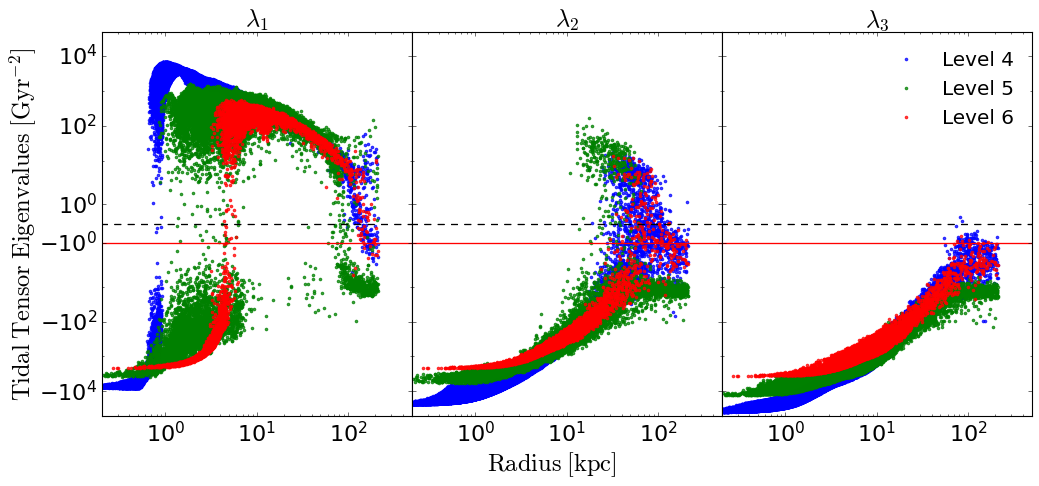

In [40]:
import matplotlib.ticker as ticker

colors = ['b', 'g', 'r']
fig, ax = plt.subplots(1, 3, sharey=True, figsize=(15,6))

for idx in range(3):
    for i in range(3):
        ax[idx].scatter(1e3*compare_radii[i], compare_tteig[i][:,-1-idx], edgecolors='face', s=5, alpha=0.75, c=colors[i], label=variations[i], rasterized=True)
        ax[idx].hlines(0, 1e-1, 5e2, color='k', linestyles='dashed')
        ax[idx].hlines(-1e0, 1e-1, 5e2, color='r')
        ax[idx].set(yscale='symlog', ylim=(-5e4, 5e4), xscale='log', xlim=(2e-1, 5e2))
        # ax[idx].set(yscale='symlog', xscale='log')
        ax[idx].tick_params(axis='both', which='both', labelsize=20)

ax[0].yaxis.set_major_locator(ticker.FixedLocator([-1e4, -1e2, -1e0, 1e0, 1e2, 1e4]))

ax[0].set_title(r'$\lambda_1$', fontsize=22)
ax[1].set_title(r'$\lambda_2$', fontsize=22)
ax[2].set_title(r'$\lambda_3$', fontsize=22)

ax[2].legend(scatterpoints=1, frameon=False, fontsize=18)

fig.text(0.06, 0.5, r'$\rm{Tidal\; Tensor\; Eigenvalues\; [Gyr^{-2}]}$', fontsize=22, ha='center', va='center', rotation='vertical')
fig.text(0.5, 0., r'$\rm{Radius\; [kpc]}$', fontsize=22, ha='center', va='center')

plt.subplots_adjust(wspace=0.0, hspace=0.0)
# plt.savefig('./plots/tteig_compare_paper.pdf', bbox_inches='tight')

In [ ]:
# in case of variations of the same simulation galaxy
plt.scatter(compare_mlrelax[0]/compare_initialmass[0], compare_mlrelax[1]/compare_initialmass[1], c=compare_initialmass[0],
            norm=plt.cm.colors.LogNorm(), cmap=cm.viridis, edgecolors='face', s=5, alpha=0.5)
plt.plot([1e-5, 1e0], [1e-5, 1e0], 'r--', linewidth=2)
plt.colorbar(label='Initial Cluster Mass [$M_\odot$]')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-5, 1)
plt.ylim(1e-5, 1)
plt.xlabel(simulation_list[0] + r' $\Delta m_\mathrm{rlx}/m_\mathrm{init}$', fontsize=14)
plt.ylabel(simulation_list[1] + r' $\Delta m_\mathrm{rlx}/m_\mathrm{init}$', fontsize=14)

In [ ]:
# in case of variations of the same simulation galaxy
plt.scatter(compare_mlshock[0]/compare_initialmass[0], compare_mlshock[1]/compare_initialmass[1], c=compare_initialmass[0],
            norm=plt.cm.colors.LogNorm(), cmap=cm.viridis, edgecolors='face', s=5, alpha=0.5)
plt.plot([1e-8, 1e0], [1e-8, 1e0], 'r--', linewidth=2)
plt.colorbar(label='Initial Cluster Mass [$M_\odot$]')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-8, 1)
plt.ylim(1e-8, 1)
plt.xlabel(simulation_list[0] + r', $\Delta m_\mathrm{sh}/m_\mathrm{init}$', fontsize=14)
plt.ylabel(simulation_list[1] + r', $\Delta m_\mathrm{sh}/m_\mathrm{init}$', fontsize=14)